In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import roots_legendre
from numba import njit
from mpmath import polylog
from scipy.optimize import minimize, root_scalar
from functools import lru_cache

In [ ]:
# Parámetros iniciales
m = 77.29158
g = 4.558428
lamda = 0.8
mu = 1
T_v = np.linspace(120, 200, 500)
mu_q_values = np.arange(0, 71, 10)
n2_puntos = 100
n3_puntos = 100
nodos2, pesos2 = roots_legendre(n2_puntos)
nodos3, pesos3 = roots_legendre(n3_puntos)

In [ ]:
  #Segunda derivada vectorizada
@lru_cache(maxsize=1000)
def cached_polylog(z):
    return float(polylog(2, z))

def PI(T_v, mu_q, g, lamda):
    T_v = np.asarray(T_v).item()
    exp_1 = -np.exp(mu_q / T_v)
    exp_2 = -np.exp(-mu_q / T_v)
    term_1 = (lamda * T_v**2) / 2
    t_2 = -((g**2 * T_v**2) / np.pi**2) * (cached_polylog(exp_1) + cached_polylog(exp_2))
    return term_1 + t_2

def D2_Int_3(T_v, mu_q, nodos2, pesos2, m, g, lamda):
    T_v = np.asarray(T_v).item()
    k_v = (1 + nodos2) / (1 - nodos2)
    dk = 2 / (1 - nodos2)**2
    Pi = PI(T_v, mu_q, g, lamda)
    arg = k_v**2
    raiz = np.sqrt(arg )
    exp_arg_1 = np.exp(-(-mu_q + raiz) / T_v)
    numerador_1 = exp_arg_1 * g**2
    denominador_1 = 1 + exp_arg_1
    exp_arg_2 = np.exp(-(mu_q + raiz) / T_v)
    numerador_2 = exp_arg_2 * g**2
    denominador_2 = 1 + exp_arg_2
    Int_vals = (16 * T_v * lamda) * k_v**2 * (
        -numerador_1 / (denominador_1 * T_v * raiz)
        -numerador_2 / (denominador_2 * T_v * raiz)
    )
    return np.sum(dk * pesos2 * Int_vals)

def D2_Int_4(T_v, mu_q, nodos3, pesos3, m, g, lamda):
    T_v = np.asarray(T_v).item()
    k_v = (1 + nodos3) / (1 - nodos3)
    dk = 2 / (1 - nodos3)**2
    Pi = PI(T_v, mu_q, g, lamda)
    arg = -m**2 + k_v**2 + Pi
    raiz = np.sqrt(arg + 0j)
    exp_arg = np.exp(-raiz / T_v)
    numerador = 3 * exp_arg * k_v**2 * lamda
    denominador = 1 - exp_arg
    Int_vals = (8 * T_v * lamda) * (numerador / (denominador * T_v * raiz))
    return np.sum(dk * pesos3 * Int_vals)

def Segunda_derivada(T_v, mu_q, lamda, m, g):
    term_1 = 1 / (16 * np.pi**2 * lamda)
    mu_m_ratio = mu**2 / m**2
    term_2 = m**2 * (
        -4 * g**4 - 16 * np.pi**2 * lamda + 9 * lamda**2
        + 3 * lamda**2 * np.log(-mu_m_ratio + 0j)
        - 3 * lamda**2 * np.log(mu_m_ratio / 2)
    )



    term_3 = D2_Int_3(T_v, mu_q, nodos2, pesos2, m, g, lamda)
    term_4 = D2_Int_4(T_v, mu_q, nodos3, pesos3, m, g, lamda)
    return term_1 * (np.real(term_2) - term_3 + term_4)

In [ ]:
# D2V = np.zeros((len(mu_q_values), len(T_v)), dtype=np.complex128)
# for i, mu_q in enumerate(mu_q_v):
#     for j, T in enumerate(T_v):
#         D2V[i, j] = Segunda_derivada(T, mu_q, lamda, m, g)


In [ ]:
# plt.figure(dpi = 100)
# plt.plot(T_v, np.real(D2V[0,:]),  color='red')#, label='Mu_q = 0 Mev')
# plt.plot(T_v, np.real(D2V[0]),  color='black')#, label='Mu_q = 10 Mev')
# plt.plot(T_v, np.real(D2V[2]),  color='blue')#, label='Mu_q = 20 Mev')
# plt.plot(T_v, np.real(D2V[3]),  color='yellow')#, label='Mu_q = 30 Mev')
# plt.plot(T_v, np.real(D2V[4]),  color='grey')#, label='Mu_q = 40 Mev')
# plt.plot(T_v, np.real(D2V[5]),  color='green')#, label='Mu_q = 50 Mev')
# plt.plot(T_v, np.real(D2V[6]),  color='pink')#, label='Mu_q = 60 Mev')
# plt.plot(T_v, np.real(D2V[7]),  color='purple')#, label='Mu_q = 70 Mev')
# plt.plot(T_v, np.real(D2V[8]),  color='brown')#, label='Mu_q = 80 Mev')
# plt.plot(T_v, np.real(D2V[9]),  color='orange')#, label='Mu_q = 90 Mev')
# plt.plot(T_v, np.real(D2V[10]),  color='violet')#, label='Mu_q = 100 Mev')
# plt.title('Parte real del potencial')
# # plt.xlim(145,158)
# # plt.ylim(-1500,1000)
# plt.xlabel('T')
# plt.ylabel('V´´2')
# plt.grid(True)
# #plt.legend()
# plt.show()

In [ ]:
#Enecuentra la raiz
def find_root(mu_q, T_v, lamda, m, g):
    def f(T):
        return np.real(Segunda_derivada(np.array([T]), mu_q, lamda, m, g))
    try:
        sol = root_scalar(f, bracket=[T_v[0], T_v[-1]], method='brentq')
        return sol.root if sol.converged else np.nan
    except ValueError:  # Manejar casos donde no hay cambio de signo
        return np.nan

#Encuentra la raiz para distintos valores de mu_q
def raiz(T_v, lamda, m, g, mu_q_values):
    respuesta = [find_root(mu_q, T_v, lamda, m, g) for mu_q in mu_q_values]
    respuesta = np.array(respuesta)
    if np.isnan(respuesta[0]) or respuesta[0] == 0:  # Evitar división por cero
        return np.full_like(respuesta, np.nan)
    return respuesta

In [ ]:
#genera las listas para graficar
tc = raiz(T_v, lamda, m, g, mu_q_values)
print(tc)

mu_bar_v = []
for i in range(len(mu_q_values)):
    mu_bar_v.append(3*(mu_q_values[i]))
mu_bar_v = np.array(mu_bar_v)

x = np.linspace(0,210,300)


[158.22511442 158.12922748 157.84118484 157.35983481 156.68323679
 155.80862925 154.73238357 153.44994302]


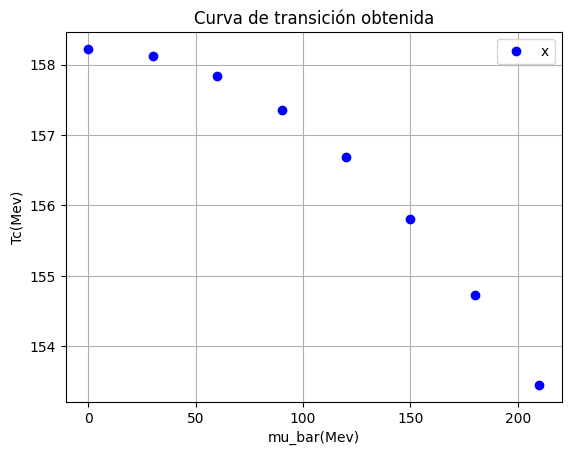

In [ ]:
#Resultado de nuestra funcion raiz
plt.figure(dpi = 100)
plt.plot(mu_bar_v, tc, 'o' ,color='blue', label='x')
#plt.plot( x, y ,color='red')#, label='Mu_q = 0 Mev')
plt.title('Curva de transición obtenida')
#plt.xlim(0,2.1)
#plt.ylim(0.94,1.001)
plt.xlabel('mu_bar(Mev)')
plt.ylabel('Tc(Mev)')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
#Discretiza la gráfica de LQCD
def Tf_QCD():
  Tc = []
  for i in range(len(mu_q_values)):
    x = 3*mu_q_values[i]
    Tc.append(158 - 0.000096*(x**2) + 8.1129e-11*(x**4))# valores multiplicados por TC_0
  Tc = np.array(Tc)
  return Tc
T_QCD_discreto = Tf_QCD()
print(T_QCD_discreto)

mu_bar_qcd = []
for i in range(len(mu_q_values)):
    mu_bar_qcd.append(3*mu_q_values[i])
mu_bar_qcd = np.array(mu_bar_qcd)

[158.         157.91366571 157.65545143 157.22772287 156.63442291
 155.88107156 154.97476598 153.92418049]


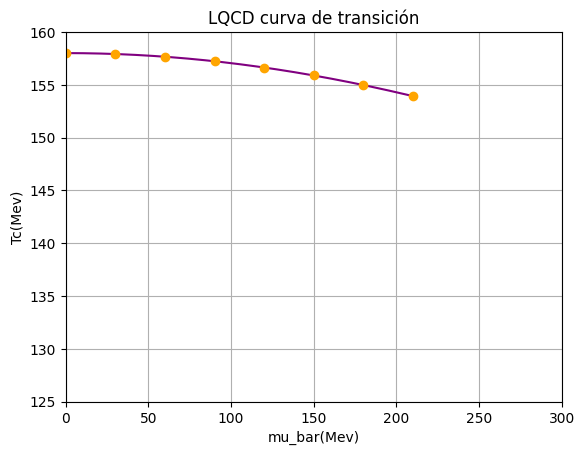

In [ ]:
#Grafica la curva de transicion de LQCD discreta y continua
T_QCD = 158 - 0.000096*x**2 + 8.1129e-11*x**4
plt.figure(dpi = 100)
plt.plot( x, T_QCD ,color='purple', label='Tc/Tc_0 = 1 - 0.0153*(mu_b/Tc_0)*2 + 0.00032(mu_b/Tc_0)**4')
plt.plot( mu_bar_qcd, T_QCD_discreto , 'o',color='orange')#, label='Mu_q = 0 Mev')
plt.title('LQCD curva de transición')
plt.xlim(0,300)
plt.ylim(125,160)
plt.xlabel('mu_bar(Mev)')
plt.ylabel('Tc(Mev)')
plt.grid(True)
plt.show()


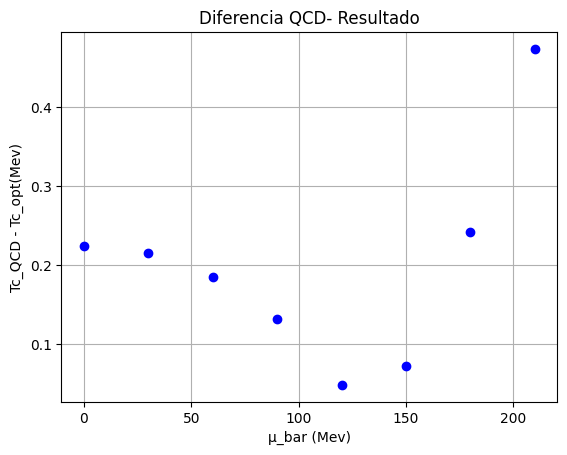

In [ ]:
#Muestra la diferencia entre los resultados obtenidos y los de QCD
plt.figure(dpi = 100)
plt.plot( mu_bar_v , np.abs(T_QCD_discreto - tc) , 'o',color='blue')#, label='Mu_q = 0 Mev')
plt.title('Diferencia QCD- Resultado')
#plt.xlim(0,2.1)
#plt.ylim(0.94,1.001)
plt.xlabel('μ_bar (Mev)')
plt.ylabel('Tc_QCD - Tc_opt(Mev)')
plt.grid(True)
plt.show()

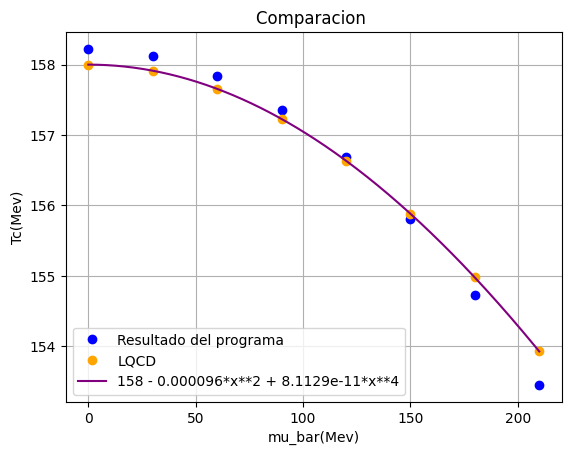

In [ ]:
# Comparacion de los resultados obtenidos
plt.figure(dpi = 100)
plt.plot(mu_bar_v, tc, 'o' ,color='blue', label='Resultado del programa')
plt.plot( mu_bar_qcd, T_QCD_discreto , 'o',color='orange', label='LQCD')
plt.plot( x, T_QCD ,color='purple', label='158 - 0.000096*x**2 + 8.1129e-11*x**4')
plt.title('Comparacion ')
#plt.xlim(0,2.1)
#plt.ylim(0.94,1.001)
plt.xlabel('mu_bar(Mev)')
plt.ylabel('Tc(Mev)')
plt.grid(True)
plt.legend()
plt.show()